# Get dataset(kaggle case)

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = r"./"
!pip install kaggle
!kaggle competitions download -c airbus-ship-detection -p .
import zipfile
import os

zip_path = "airbus-ship-detection.zip"
extract_dir = "./airbus_data"

# Make sure target folder exists
os.makedirs(extract_dir, exist_ok=True)

# Extract with progress info
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print(f"Extracting {len(zip_ref.infolist())} files...")
    zip_ref.extractall(extract_dir)

print("✅ Extraction complete.")

In [1]:
import pandas as pd
import os

#Get data tturn csv into pandas dataset
DATA_DIR      = './airbus_data/'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_v2")
TEST_IMG_DIR  = os.path.join(DATA_DIR, "test_v2")
train_csv = os.path.join(DATA_DIR, 'train_ship_segmentations_v2.csv')
train_df = pd.read_csv(train_csv)
print(train_df.shape)
train_df.head()


(231723, 2)


,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [2]:
# Missing values (if no ship -> encoded pixels is nan)
missing_masks = train_df['EncodedPixels'].isnull().sum()
print("Pictures without boats:", missing_masks)
not_missing_masks = train_df['EncodedPixels'].notnull().sum()
print("Pictures with boats", not_missing_masks)
# One picture can have more masks -> needs grouping
unique_images = train_df['ImageId'].nunique()
print("Unique pictures:", unique_images)


Pictures without boats: 150000
Pictures with boats 81723
Unique pictures: 192556


In [3]:
# Filter duplications
train_df = train_df.drop_duplicates(subset=['ImageId', 'EncodedPixels'])
# Checking actual existance of files
train_images = set(os.listdir(os.path.join(DATA_DIR, 'train_v2')))
train_df = train_df[train_df['ImageId'].isin(train_images)]
train_df.head()

,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [4]:
# Labeling(1 if has ship else 0)
train_df['has_ship'] = train_df['EncodedPixels'].notnull().astype(int)

# Group all rows that belong to same image
image_grouped = train_df.groupby('ImageId')['has_ship'].max().reset_index()
image_grouped.rename(columns={'has_ship': 'has_ship_label'}, inplace=True)

# Balancing due to lot of empty pictures -> 1:2 ratio of has ships and no ships so it doesnt overfit.
positive = image_grouped[image_grouped['has_ship_label'] == 1]
negative = image_grouped[image_grouped['has_ship_label'] == 0].sample(len(positive) * 2, random_state=42)
balanced_df = pd.concat([positive, negative])


## Decode RLE masks
This cell defines rle_decode to convert run-length encoding to a binary mask array. 


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# Take in rle string and output binary mask with given shape
def rle_decode(mask_rle, shape=(768, 768)):
    # Return full black mask if RLE is missing
    if pd.isnull(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    
    s = mask_rle.split()
    # RLE odd nums -> length even nums-> start values
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[::2], s[1::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T  # Transpose to align with right direction


In [6]:
# Split dataframe into validation, train and test

In [7]:
from sklearn.model_selection import train_test_split
# split into TRAIN(90%) and TEMP(10%)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.1,
    random_state=42,
    stratify=balanced_df["has_ship_label"] # ensure that we keep the same ratio of ships/no-ships pictures
)
# split TEMP INTO VALIDATION(5%) AND TEST(5%) 
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['has_ship_label']
)

train_ids = train_df['ImageId'].values
val_ids = val_df['ImageId'].values
test_ids = test_df['ImageId'].values

print(f"Total Balanced Images: {len(balanced_df)}")
print(f"---------------------------------------")
print(f"Train Size (90%): {len(train_ids)} images")
print(f"Val Size    (5%): {len(val_ids)} images")
print(f"Test Size   (5%): {len(test_ids)} images")

Total Balanced Images: 127668
---------------------------------------
Train Size (90%): 114901 images
Val Size    (5%): 6383 images
Test Size   (5%): 6384 images


## Custom PyTorch Dataset for Airbus Ship Detection
**__init__:**
- Stores the input dataframe (df) and image directory path (base_path).
- Loads the CSV containing all RLE-encoded masks.
- Saves any optional augmentations or preprocessing transforms (e.g., resize, normalize).
**__getitem__:**
- Retrieves the image filename using the given index.
- Opens the corresponding image and converts it to RGB.
- Collects all mask rows belonging to that image ID, decodes them from RLE, and merges them into one binary mask (768×768).
- Applies Albumentations transforms jointly on the image and mask to keep them spatially consistent.
- Returns the processed (image, mask) pair as tensors ready for model input.

In [8]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
import os
import pandas as pd

class AirbusDataset(Dataset):
    def __init__(self, image_ids, img_dir, mask_df, transforms=None):
        self.image_ids = image_ids
        self.img_dir = img_dir
        self.transforms = transforms
        self.mask_groups = mask_df.groupby('ImageId')

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        # 1. Load Image
        try:
            image = np.array(Image.open(img_path).convert("RGB"))
        except Exception as e:
            # HIBAKEZELÉS JAVÍTVA:
            # Nem térünk vissza azonnal (return), hanem létrehozunk egy üres képet.
            # Így ez is lemegy majd a transzformációkon (Resize), és 384x384 lesz.
            print(f"Warning: Error loading {img_name}, using empty mask.")
            image = np.zeros((768, 768, 3), dtype=np.uint8)

        # 2. Get Masks (Fast Lookup)
        try:
            img_masks = self.mask_groups.get_group(img_name)
        except KeyError:
            img_masks = pd.DataFrame()

        # 3. Decode RLE
        mask = np.zeros((768, 768), dtype=np.float32)
        if not img_masks.empty:
            for _, row in img_masks.iterrows():
                if isinstance(row['EncodedPixels'], str):
                    mask += rle_decode(row['EncodedPixels'])
        
        mask = np.clip(mask, 0, 1)

        # 4. Augmentations (MOST MÁR A HIBÁS KÉP IS ITT HALAD ÁT!)
        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        return image, mask

Training Set Size: 114901


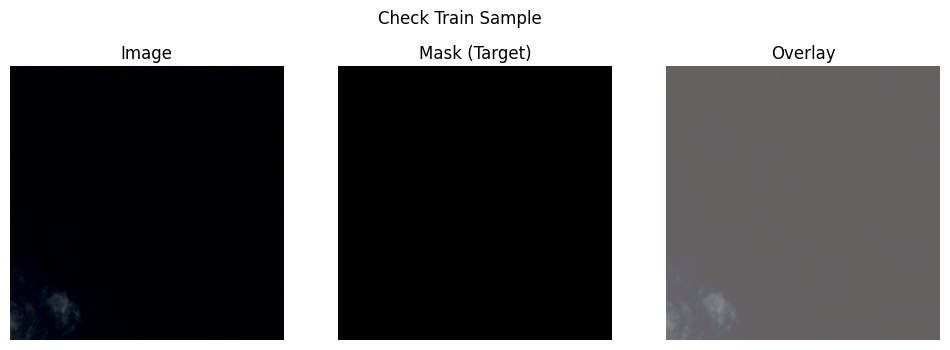

In [9]:
# 1. Reload the full mask data (we need the RLE strings)
masks = pd.read_csv(os.path.join(DATA_DIR, 'train_ship_segmentations_v2.csv'))

# 2. Define Augmentations (Standard ImageNet stats help convergence)
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 384

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    # Normalize inputs to 0-1 range using standard ImageNet mean/std
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# 3. Create the Datasets (Using the lists of IDs we created in Phase 1)
train_dataset = AirbusDataset(train_ids, TRAIN_IMG_DIR, masks, transforms=train_transforms)
val_dataset   = AirbusDataset(val_ids,   TRAIN_IMG_DIR, masks, transforms=val_transforms)
test_dataset  = AirbusDataset(test_ids,  TRAIN_IMG_DIR, masks, transforms=val_transforms)

# 4. Visualize to verify (Sanity Check)
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(dataset, index=0, title="Sample"):
    image, mask = dataset[index]
    
    # Un-normalize image for display (reverse the A.Normalize step)
    if hasattr(image, "permute"):
        image_np = image.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = (image_np * std) + mean
        image_np = np.clip(image_np, 0, 1)
    else:
        image_np = np.array(image)

    # Handle mask
    mask_np = mask if not hasattr(mask, "cpu") else mask.cpu().numpy()

    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Mask (Target)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(image_np)
    plt.imshow(mask_np, alpha=0.4, cmap="Reds")
    plt.title("Overlay")
    plt.axis("off")
    plt.show()

# Check a few samples to make sure ships line up with masks
print(f"Training Set Size: {len(train_dataset)}")
visualize_sample(train_dataset, index=10, title="Check Train Sample")

In [10]:
from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 20 # Ha "Out of Memory" hibát kapsz, vedd le 4-re
NUM_WORKERS = 0 # Windows-on a 0 a legbiztonságosabb (elkerüli a fagyást)

# 1. Train Loader
train_loader = DataLoader(
    train_dataset,          # Ezt hoztuk létre az előző lépésekben
    batch_size=BATCH_SIZE,
    shuffle=True,           # Tanításnál mindig keverjük az adatokat!
    num_workers=NUM_WORKERS,
    pin_memory=True         # Gyorsítja az adatmozgatást GPU-ra
)

# 2. Validation Loader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # Validációnál NEM kell keverni
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 5746
Val batches:   320


In [11]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

class DoubleConv(nn.Module):
    """
    A helper block: (Convolution => BN => ReLU) * 2
    Every step in U-Net essentially does this twice.
    """
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # First Conv Layer
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Second Conv Layer
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Encoder Part (Going Down) ---
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # --- Bottleneck (Floor) ---
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # --- Decoder Part (Going Up) ---
        for feature in reversed(features):
            # Upsampling: Doubles the spatial dimensions (H, W)
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # --- Final Output Layer ---
        # Reduces features to 1 channel (Ship vs Background)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # 1. Run Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x) # Save output for skip connection
            x = self.pool(x)

        # 2. Run Bottleneck
        x = self.bottleneck(x)

        # Reverse skip connections list (we need the last one first)
        skip_connections = skip_connections[::-1]

        # 3. Run Decoder
        for idx in range(0, len(self.ups), 2):
            # Upsample
            x = self.ups[idx](x)
            
            # Get the corresponding skip connection
            skip_connection = skip_connections[idx//2]

            # Resize if dimensions don't match perfectly (rare with 768x768 but good safety)
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])

            # Concatenate skip connection with current input
            concat_skip = torch.cat((skip_connection, x), dim=1)
            
            # Run Double Convolution
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

# Initialize the model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(in_channels=3, out_channels=1)
if torch.cuda.device_count() > 1:
    print(f"Parallel training is on")
    model = nn.DataParallel(model)

model.to(DEVICE)
print("Custom U-Net model created!")

Parallel training is on
Custom U-Net model created!


In [12]:
import torch.optim as optim

# --- LOSS FUNCTION ---
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets):
        # 1. BCE Loss (Pixel-wise accuracy)
        bce = self.bce(inputs, targets)
        
        # 2. Dice Loss (Overlap metric for unbalanced data)
        inputs = torch.sigmoid(inputs) # Convert logits to probabilities (0-1)
        
        # Flatten tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + 1) / (inputs.sum() + targets.sum() + 1)
        
        # Final combined loss
        return bce + (1 - dice)

# Setup

loss_fn = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Standard learning rate
scaler = torch.amp.GradScaler('cuda')


# --- TRAINING FUNCTION ---
from tqdm.notebook import tqdm

def train_fn(loader, model, optimizer, loss_fn, scaler):
    model.train()
    loop = tqdm(loader, desc="Training")
    epoch_loss = 0

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(DEVICE)
        # Add channel dimension to mask: [Batch, H, W] -> [Batch, 1, H, W]
        targets = targets.float().unsqueeze(1).to(DEVICE)

        # Mixed Precision Forward Pass
        with torch.amp.autocast('cuda'):
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        # Backward Pass
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Logging
        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    return epoch_loss / len(loader)

In [13]:
def validate(model, loader, loss_fn, device,threshold = 0.5):
    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    model.eval()
    running_loss = 0.0
    with torch.no_grad(): 
        for images, masks in loader:
            images = images.to(device).float()
            masks = masks.to(device).float().unsqueeze(1)
            
            predictions = model(images)
            loss = loss_fn(predictions, masks)
            
            running_loss += loss.item()
            preds_binary = (torch.sigmoid(predictions) > threshold).float()
            masks_binary = masks
            tp = ((preds_binary == 1) & (masks_binary == 1)).sum().item()
            fp = ((preds_binary == 1) & (masks_binary == 0)).sum().item()
            fn = ((preds_binary == 0) & (masks_binary == 1)).sum().item()
            tn = ((preds_binary == 0) & (masks_binary == 0)).sum().item()
            
            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_tn += tn
            
    avg_loss = running_loss / len(loader)
    
    # Calculate metrics
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    iou = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0
    
    metrics = {
        'loss': avg_loss,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'tn': total_tn,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'iou': iou
    }
    
    return metrics

In [ ]:
NUM_EPOCHS = 1
patience = 1
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    avg_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler)
    print(f"Average Loss: {avg_loss:.4f}")
    val_metrics = validate(model, val_loader, loss_fn, DEVICE)
    print(f"Validation Loss: {val_metrics['loss']:.4f}")
    print(f"TP: {val_metrics['tp']:,} | FP: {val_metrics['fp']:,} | "
          f"FN: {val_metrics['fn']:,} | TN: {val_metrics['tn']:,}")
    print(f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f}")
    print(f"F1 Score: {val_metrics['f1_score']:.4f} | IoU: {val_metrics['iou']:.4f}")
    
    # Best model save
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        torch.save(model.state_dict(), "custom_unet_best.pth")
        print(f"New best model saved! (val_loss = {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epoch(s).")
        
        if patience_counter >= patience:
            print("Early stopping, no validation improvement.")
            break

Epoch 1/1


Training:   0%|          | 0/5746 [00:00<?, ?it/s]

C:\Users\PC\anaconda3\envs\AIRBUS\lib\site-packages\torch\cuda\nccl.py:16: UserWarning: PyTorch is not compiled with NCCL support
  warnings.warn("PyTorch is not compiled with NCCL support")


In [ ]:
def check_accuracy(loader, model, device="cuda"):
    model.eval() # Értékelő mód (kikapcsolja a dropoutot, stb.)
    dice_score = 0
    
    print("Validáció futtatása...")
    with torch.no_grad(): # Nem számolunk gradienseket, gyorsabb
        for x, y in tqdm(loader):
            x = x
            y = y.unsqueeze(1)
            
            # A modell kimenete (logits)
            preds = torch.sigmoid(model(x))
            
            # Binarizálás (0 vagy 1)
            preds = (preds > 0.5).float()
            preds = preds.cpu()
            y = y.cpu()
            
            # Dice számítás
            intersection = (preds * y).sum()
            dice_score += (2. * intersection) / (preds.sum() + y.sum() + 1e-8)

    final_score = dice_score/len(loader)
    print(f"Validation Dice Score: {final_score:.4f}")
    model.train() # Vissza tanító módba
    return final_score

# Futtasd le a validációt!
# Ez sokkal gyorsabb lesz, mint a tanítás (kb. 5-10 perc)
val_dice = check_accuracy(val_loader, model)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_results(loader, model, device="cuda", num_samples=5):
    model.eval()

    samples_shown = 0
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).unsqueeze(1)
            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float()
            
            # Vissza CPU-ra
            x = x.cpu().numpy()
            y = y.cpu().numpy()
            preds = preds.cpu().numpy()
            
            for i in range(x.shape[0]):
                # Csak olyan képet mutassunk, ahol VAN hajó (hogy lássuk a találatot)
                if y[i].sum() > 0: 
                    if samples_shown >= num_samples:
                        return

                    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
                    
                    # Kép normalizálás visszaállítása (hogy látható legyen)
                    img = np.transpose(x[i], (1, 2, 0))
                    mean = np.array([0.485, 0.456, 0.406])
                    std = np.array([0.229, 0.224, 0.225])
                    img = std * img + mean
                    img = np.clip(img, 0, 1)
                    
                    ax1.imshow(img)
                    ax1.set_title("Eredeti Kép")
                    ax1.axis("off")
                    
                    ax2.imshow(y[i][0], cmap="gray")
                    ax2.set_title("Valós Maszk (Ahol a hajó van)")
                    ax2.axis("off")
                    
                    ax3.imshow(preds[i][0], cmap="gray")
                    ax3.set_title("Modell Tippje")
                    ax3.axis("off")
                    
                    plt.show()
                    samples_shown += 1

# Nézzünk meg pár eredményt!
visualize_results(val_loader, model)

In [ ]:
import cv2
import numpy as np

def count_ships(mask):
    # mask: torch.Tensor vagy numpy array, 0/1 értékekkel
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()

    mask = (mask > 0).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(mask)
    return num_labels - 1, labels  # -1 because label 0 is background


In [ ]:
def component_iou(pred_labels, gt_labels, pred_id, gt_id):
    pred_mask = (pred_labels == pred_id)
    gt_mask   = (gt_labels == gt_id)

    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()

    if union == 0:
        return 0.0
    return intersection / union


In [ ]:
def evaluate_ship_detection(pred_mask, gt_mask, iou_threshold=0.3):
    pred_count, pred_labels = count_ships(pred_mask)
    gt_count, gt_labels = count_ships(gt_mask)

    matched_pred = set()
    matched_gt = set()

    # IoU alapú összepárosítás
    for p_id in range(1, pred_count + 1):
        for g_id in range(1, gt_count + 1):
            iou = component_iou(pred_labels, gt_labels, p_id, g_id)
            if iou >= iou_threshold:
                matched_pred.add(p_id)
                matched_gt.add(g_id)

    TP = len(matched_pred)
    FN = gt_count - TP
    FP = pred_count - TP

    return TP, FP, FN
